# Demo 01: Echogram fu
### `themachinethatgoesping` tutorial series

Here we show how to create echograms from acoustic data and how to do magic with them

In [1]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict
from time import time

import os

folder = '/home/data/test_data/Egmont_Key/kmall/'

files = sorted(theping.echosounders.index_functions.find_files(folder,['.kmall', '.kmwcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)

# create the file handler
#fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files[1:3], cache_files)
fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files, cache_files)

# get pings that contain WCD?
pings = theping.pingprocessing.filter_pings.by_features(fh_mbes.get_pings(),['watercolumn.amplitudes'])

pss = theping.echosounders.pingtools.PingSampleSelector()
#pss.select_beam_range_by_angles(-3,3)

depth_stack=True

#load echogram once to avoid potential caching errors for benchmarking
# echogram= theping.pingprocessing.watercolumn.echograms.EchogramBuilder.from_pings(
#         pings,
#         pss=pss,
#         wci_value = 'av/rv/pv',
#         linear_mean=False,
#         verbose=False)

t0 = time()
echogram= theping.pingprocessing.watercolumn.echograms.EchogramBuilder.from_pings(
        pings,
        pss=pss,
        wci_value = 'av/rv/pv',
        depth_stack=depth_stack,
        linear_mean=False,
        verbose=False)

t1 = time()
print('init (old):',round(t1-t0,2))
echogram_new = theping.pingprocessing.watercolumn.echograms.EchogramBuilder2.from_pings(
        pings,
        pss=pss,
        wci_value = 'av/rv/pv',
        depth_stack=depth_stack,
        linear_mean=False,
        verbose=False)

t2 = time()
print('init (new):',round(t2-t1,2))
echogram.set_x_axis_date_time(max_steps=1000)
echogram.set_y_axis_depth()

t3 = time()
print('axis (old):',round(t3-t2,2))
echogram_new.set_x_axis_date_time(max_steps=1000)
echogram_new.set_y_axis_depth()

t4 = time()
print('axis (new):',round(t4-t3,2))
echogramviewer = theping.widgets.EchogramViewer(echogram, name='old')

t5 = time()
echogramviewer = theping.widgets.EchogramViewer(echogram_new,name='new', auto_update=True, auto_update_delay_ms=100)

t6=time()
print('viewer (old):',round(t5-t4,2))
print('viewer (new):',round(t6-t5,2))

Found 26 files
indexing files ⢀ 99% :00s<00m:00s] [Found: 393309 datagrams in 26 files (16645MB)]                                               
Initializing ping interface ⡀ 94% :01s<00m:00s] [Done]                                                                             
init (old): 11.44
init (new): 3.83
axis (old): 0.86
axis (new): 0.01


viewer (old): 0.71
viewer (new): 0.46


In [2]:
for e in [echogram_new]:
    layer_name='test'
    e.add_layer_from_ping_param_offsets_relative(layer_name,'minslant',0,0.95)
    e.add_layer_from_ping_param_offsets_absolute(layer_name,'echosounder', 1,1000)


In [2]:
echogram_new.to_zarr('test3.zarr', compressor='lz4')

Writing WCI data:   0%|          | 0/1175 [00:00<?, ?chunk/s, pings/s=2687]

/home/peurban/.local/share/mamba/envs/dev/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


'test3.zarr'

In [4]:
echogram_new.to_mmap('test.mmap')

Exporting (10MB chunks):   9%|9         | 1/11 [00:01<00:14,  1.47s/chunk]

'test.mmap'

In [1]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict
from time import time

import os

file = 'test2.zarr'

t00 = time()
echogram_zarr= theping.pingprocessing.watercolumn.echograms.EchogramBuilder2.from_zarr(file)

t01 = time()
print('init (zarr):',round(t01-t00,2))

echogram_zarr.set_x_axis_date_time(max_steps=10000)
echogram_zarr.set_y_axis_depth()

t02 = time()
print('axis (zarr):',round(t02-t01,2))
echogramviewer = theping.widgets.EchogramViewer(echogram_zarr, name='zarr')

t03=time()
print('viewer (zarr):',round(t03-t02,2))

echogram_zarr.build_image()
t04=time()
print('build_image (zarr):',round(t04-t03,2))

init (zarr): 0.21
axis (zarr): 0.01


viewer (zarr): 0.52
build_image (zarr): 0.39


In [2]:
echogram_zarr.to_zarr('tmp.zarr')

Writing WCI data:   0%|          | 0/1175 [00:00<?, ?chunk/s, pings/s=10605]

/home/peurban/.local/share/mamba/envs/dev/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


'tmp.zarr'

In [3]:
echogram_zarr.to_mmap('test.mmap')

Exporting (10MB chunks):   0%|          | 0/11 [00:00<?, ?chunk/s, pings/s=191727]

'test.mmap'

In [1]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict
from time import time

import os

folder = '/home/data/test_data/Egmont_Key/kmall/'

files = sorted(theping.echosounders.index_functions.find_files(folder,['.kmall', '.kmwcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)

# create the file handler
#fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files[1:3], cache_files)
fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files, cache_files)

# get pings that contain WCD?
pings = theping.pingprocessing.filter_pings.by_features(fh_mbes.get_pings(),['watercolumn.amplitudes'])

pss = theping.echosounders.pingtools.PingSampleSelector()
#pss.select_beam_range_by_angles(-3,3)

depth_stack=True

echogram_new = theping.pingprocessing.watercolumn.echograms.EchogramBuilder2.from_pings(
        pings,
        pss=pss,
        wci_value = 'av/rv/pv',
        depth_stack=depth_stack,
        linear_mean=False,
        verbose=False)

Found 26 files
indexing files ⠈ 99% :00s<00m:00s] [Found: 393309 datagrams in 26 files (16645MB)]                                               
Initializing ping interface ⠂ 94% :01s<00m:00s] [Done]                                                                             


In [7]:
import importlib
from pathlib import Path
import themachinethatgoesping.pingprocessing.watercolumn.echograms.pyramid
importlib.reload(themachinethatgoesping.pingprocessing.watercolumn.echograms.pyramid)

pyramid = themachinethatgoesping.pingprocessing.watercolumn.echograms.pyramid.TiledEchogramPyramid(
    echogram_new, 
    cache_dir=Path("~/.cache/echograms"),  # Optional disk cache
)
pyramid.ensure_overview()  # Build overview once (cached to disk)

In [8]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict
from time import time

import os

import importlib
import themachinethatgoesping.widgets.echogramviewer
import themachinethatgoesping.widgets.echogramviewer_pyqtgraph
importlib.reload(themachinethatgoesping.widgets.echogramviewer_pyqtgraph)
importlib.reload(themachinethatgoesping.widgets.echogramviewer)
EchogramViewer = themachinethatgoesping.widgets.echogramviewer_pyqtgraph.EchogramViewerPyQtGraph
#EchogramViewer = themachinethatgoesping.widgets.echogramviewer.EchogramViewer

file = 'test.mmap'

t00 = time()
echogram_mmap= theping.pingprocessing.watercolumn.echograms.EchogramBuilder2.from_mmap(file)

echogram = echogram_mmap
echogram = echogram_new
echogram = pyramid

t01 = time()
print('init (mmap):',round(t01-t00,2))

echogram.set_x_axis_date_time(max_steps=3000)
echogram.set_y_axis_depth()

t02 = time()
print('axis (mmap):',round(t02-t01,2))
echogramviewer = EchogramViewer(echogram, name='mmap', auto_update=True, auto_update_delay_ms=50, cmap='YlGnBu_r')

t03=time()
print('viewer (mmap):',round(t03-t02,2))
echogram.build_image()
t04=time()
print('build_image (mmap):',round(t04-t03,2))

init (mmap): 0.06
axis (mmap): 0.01


QColorSpace attempted constructed from invalid primaries: QPointF(0.313477,0.329102) QPointF(0.691406,0.318359) QPointF(0.266602,0.682617) QPointF(0.151367,0.0585938)


RFBOutputContext()

viewer (mmap): 0.15
build_image (mmap): 0.0


ModuleNotFoundError: No module named 'themachinethatgoesping.pingprocessing.watercolumn.echograms.pyramids'

In [11]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict
from time import time

import os

import importlib
import themachinethatgoesping.widgets.echogramviewer
import themachinethatgoesping.widgets.echogramviewer_pyqtgraph
importlib.reload(themachinethatgoesping.widgets.echogramviewer_pyqtgraph)
importlib.reload(themachinethatgoesping.widgets.echogramviewer)
EchogramViewer = themachinethatgoesping.widgets.echogramviewer_pyqtgraph.EchogramViewerPyQtGraph
#EchogramViewer = themachinethatgoesping.widgets.echogramviewer.EchogramViewer

file = 'test.mmap'

t00 = time()
echogram_mmap= theping.pingprocessing.watercolumn.echograms.EchogramBuilder2.from_mmap(file)

echogram = echogram_mmap
echogram = echogram_new

t01 = time()
print('init (mmap):',round(t01-t00,2))

echogram.set_x_axis_date_time(max_steps=3000)
echogram.set_y_axis_depth()

t02 = time()
print('axis (mmap):',round(t02-t01,2))
echogramviewer = EchogramViewer(echogram, name='mmap', auto_update=True, auto_update_delay_ms=300, cmap='YlGnBu_r')

t03=time()
print('viewer (mmap):',round(t03-t02,2))
echogram.build_image()
t04=time()
print('build_image (mmap):',round(t04-t03,2))

init (mmap): 0.04
axis (mmap): 0.01


RFBOutputContext()

viewer (mmap): 1.45
build_image (mmap): 1.36


In [3]:
for e in [echogram_mmap]:
    layer_name='test'
    e.add_layer_from_ping_param_offsets_relative(layer_name,'minslant',0,0.95)
    e.add_layer_from_ping_param_offsets_absolute(layer_name,'echosounder', 1,1000)


In [5]:
%%timeit -n1 -r1
echogram.build_image()

NameError: name 'echogram' is not defined

In [6]:
%%timeit -n1 -r1
echogram_new.build_image()

NameError: name 'echogram_new' is not defined

In [7]:
%%timeit -n1 -r1
echogram_zarr.build_image()

376 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [8]:
%%timeit -n1 -r1
echogram_mmap.build_image()

45.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [2]:
for e in [echogram_zarr,echogram_mmap]
    layer_name='test'
    e.add_layer_from_ping_param_offsets_relative(layer_name,'minslant',0,0.95)
    e.add_layer_from_ping_param_offsets_absolute(layer_name,'echosounder', 1,1000)

In [16]:
if 'l' in globals():
    l[0].remove()
    del l
l = echogramviewer.axes[0].plot(*echogram.get_ping_param('minslant'),c='black')

In [24]:
echogram_new.remove_layer('main')
echogram.remove_layer('main')
echogram_new.remove_layer('test')
echogram.remove_layer('test')
echogram_new.add_layer_from_ping_param_offsets_relative('main','minslant',0,0.95)
echogram.add_layer_from_ping_param_offsets_relative('main','minslant',0,0.95)
echogram_new.add_layer_from_ping_param_offsets_absolute('main','echosounder', 1,1000)
echogram.add_layer_from_ping_param_offsets_absolute('main','echosounder', 1,1000)

In [3]:
echogram_new.param.keys()

dict_keys(['bottom', 'minslant', 'echosounder'])

In [10]:
# internal Ping.pingprocessing packages
from themachinethatgoesping.pingprocessing.core.progress import get_progress_iterator
from themachinethatgoesping.pingprocessing.core.asserts import assert_length, assert_valid_argument
from themachinethatgoesping.algorithms.geoprocessing.functions import to_raypoints
from themachinethatgoesping.algorithms.gridding import ForwardGridder1D

from themachinethatgoesping.algorithms_nanopy.featuremapping import NearestFeatureMapper

from themachinethatgoesping.pingprocessing.watercolumn import helper as wchelper

self=echogram
nr=10
from_bottom_xyz=False
sel = self.beam_sample_selections[nr]

if not sel.empty():
    ping = self.pings[nr]

    # select which ping.watercolumn.get_ function to call based on wci_value
    wci = wchelper.select_get_wci_image(ping, sel, self.wci_value, self.mp_cores)

    if from_bottom_xyz:
        xyz, bd, bdsn = wchelper.make_image_helper.get_bottom_directions_bottom(ping, selection=sel)
    else:
        xyz, bd, bdsn = wchelper.make_image_helper.get_bottom_directions_wci(ping, selection=sel)

    geolocation = ping.get_geolocation()

    # y = to_raypoints(
    #     0.,
    #     np.array(xyz.y).astype(np.float32),
    #     0.5,
    #     np.array(bdsn+0.5).astype(np.float32),
    #     np.array(range(wci.shape[1])).astype(np.float32))

    z = to_raypoints(
        geolocation.z,
        np.array(xyz.z).astype(np.float32),
        0.5,
        np.array(bdsn + 0.5).astype(np.float32),
        np.array(range(wci.shape[1])).astype(np.float32),
    )

    arg = np.where(np.isfinite(wci.flatten()))

    if self.linear_mean:
        wci = np.power(10, 0.1 * wci.flatten()[arg])
    # y = y.flatten()[arg]
    z = z.flatten()[arg]

    v, w = self.y_gridder.interpolate_block_mean(z, wci)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        if self.linear_mean:
            column = 10 * np.log10(v / w)
        else:
            column = v / w

TypeError: interpolate_block_mean(): incompatible function arguments. The following argument types are supported:
    1. interpolate_block_mean(self, sx: numpy.ndarray[dtype=float64, shape=(*), order='A'], s_val: numpy.ndarray[dtype=float64, shape=(*), order='A']) -> tuple[numpy.ndarray[dtype=float64, shape=(*), order='A'], numpy.ndarray[dtype=float64, shape=(*), order='A']]

Invoked with types: themachinethatgoesping.algorithms_nanopy.gridding.ForwardGridder1D, ndarray, ndarray

In [18]:
z.shape

(5292,)

In [19]:
wci.shape[0]*wci.shape[1]

5292

In [ ]:
theping.algorithms.geoprocessing.functions.to_raypoints(

In [ ]:
for ping in tqdm(pings):
    ping.watercolumn.get_rv()

  0%|          | 0/82240 [00:00<?, ?it/s]

In [1]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict
from time import time

import os

folder = '/home/data/test_data/Egmont_Key/kmall/'

files = sorted(theping.echosounders.index_functions.find_files(folder,['.kmall', '.kmwcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)

# create the file handler
fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files, cache_files)

# get pings that contain WCD?
pings = theping.pingprocessing.filter_pings.by_features(fh_mbes.get_pings(),['watercolumn.amplitudes'])

Found 27 files
indexing files ⢀ 99% :00s<00m:00s] [Found: 416333 datagrams in 27 files (17326MB)]                                               
Initializing ping interface ⠂ 94% :06s<00m:00s] [Done]                                              


In [14]:
nr=35536
nr=35540
nr=35538
ping = pings[nr]

In [15]:
wc = ping.file_data.datagrams("#MWC")[0]
wc.beam_data.get_total_number_of_samples()

4154737

In [16]:
print(wc)

MWaterColumn
############
- bytes_datagram:      64000      [bytes]
- datagram_identifier: #MWC       [M_WATER_COLUMN]
- datagram_version:    2          
- system_id:           40         
- echo_sounder_id:     2040       
- time_sec:            1722004802 [s]
- time_nanosec:        432875314  [ns]

 date/time 
-----------  
- timestamp: 1722.005e⁶   [s]
- date:      26/07/2024   [MM/DD/YYYY]
- time:      14:40:02.433 [HH:MM:SS]

 MPartition part 
----------------- 
- number_of_datagrams: 2 
- datagram_number:     1 

 datagram content 
------------------ 
- bytes_content:            12    
- ping_count:               28455 
- rx_fans_per_ping:         1     
- rx_fan_index:             0     
- swaths_per_ping:          1     
- swath_along_position:     0     
- tx_transducer_ind:        0     
- rx_transducer_ind:        0     
- number_of_rx_transducers: 1     
- algorithm_type:           0     

 Tx info (.tx_info) 
-------------------- 
- bytes_content:           12            [

In [54]:
print(wc.beam_data.get_total_number_of_samples())
for i,b in enumerate(wc.beam_data.get_beams()):
    print(i,b.get_number_of_samples())

96768
0 378
1 378
2 378
3 378
4 378
5 378
6 378
7 378
8 378
9 378
10 378
11 378
12 378
13 378
14 378
15 378
16 378
17 378
18 378
19 378
20 378
21 378
22 378
23 378
24 378
25 378
26 378
27 378
28 378
29 378
30 378
31 378
32 378
33 378
34 378
35 378
36 378
37 378
38 378
39 378
40 378
41 378
42 378
43 378
44 378
45 378
46 378
47 378
48 378
49 378
50 378
51 378
52 378
53 378
54 378
55 378
56 378
57 378
58 378
59 378
60 378
61 378
62 378
63 378
64 378
65 378
66 378
67 378
68 378
69 378
70 378
71 378
72 378
73 378
74 378
75 378
76 378
77 378
78 378
79 378
80 378
81 378
82 378
83 378
84 378
85 378
86 378
87 378
88 378
89 378
90 378
91 378
92 378
93 378
94 378
95 378
96 378
97 378
98 378
99 378
100 378
101 378
102 378
103 378
104 378
105 378
106 378
107 378
108 378
109 378
110 378
111 378
112 378
113 378
114 378
115 378
116 378
117 378
118 378
119 378
120 378
121 378
122 378
123 378
124 378
125 378
126 378
127 378
128 378
129 378
130 378
131 378
132 378
133 378
134 378
135 378
136 378
137 378


In [28]:
print(wc.beam_data.get_beams()[162])

MWCRxBeamData
#############
- beam_pointing_angle_re_vertical_deg:       -14.898 [°]
- start_range_sample_number:                 0       
- detected_range_in_samples:                 175     [samples]
- transmit_sector_number:                    0       
- number_of_samples:                         378     
- detected_range_in_samples_high_resolution: 175.772 [samples]

 sample data 
-------------                                     
- sample_amplitudes_05dB: {-128, -128, -128, ..., -85, -84, -63} 
                         ... Min:  -112 | Max: -118 | Mean: 0 | Median: -79
                         ... 378 elements


In [27]:
print(wc.beam_data.get_beams()[163])

MWCRxBeamData
#############
- beam_pointing_angle_re_vertical_deg:       -6413.410e³   [°]
- start_range_sample_number:                 51640         
- detected_range_in_samples:                 52937         [samples]
- transmit_sector_number:                    52174         
- number_of_samples:                         53712         
- detected_range_in_samples_high_resolution: -1793.222e⁶   [samples]

 sample data 
-------------                               
- sample_amplitudes_05dB: {-97, -54, -47, ..., 18, 0, -17} 
                         ... Min:  -128 | Max: -128 | Mean: 343438041288902 | Median: -72
                         ... 53712 elements


In [5]:
ping.file_data.datagrams("#MWC")[0].print()

MWaterColumn
############
- bytes_datagram:      64000      [bytes]
- datagram_identifier: #MWC       [M_WATER_COLUMN]
- datagram_version:    2          
- system_id:           40         
- echo_sounder_id:     2040       
- time_sec:            1722004802 [s]
- time_nanosec:        328994506  [ns]

 date/time 
-----------  
- timestamp: 1722.005e⁶   [s]
- date:      26/07/2024   [MM/DD/YYYY]
- time:      14:40:02.329 [HH:MM:SS]

 datagram content 
------------------ 
- bytes_content:            12    
- ping_count:               28453 
- rx_fans_per_ping:         1     
- rx_fan_index:             0     
- swaths_per_ping:          1     
- swath_along_position:     0     
- tx_transducer_ind:        0     
- rx_transducer_ind:        0     
- number_of_rx_transducers: 1     
- algorithm_type:           0     

 Tx info (.tx_info) 
-------------------- 
- bytes_content:           12            [bytes]
- number_of_tx_sectors:    1             
- num_bytes_per_tx_sector: 16            

In [ ]:
ping.watercolumn.get_rv()

In [ ]:
pings[nr].watercolumn.get_rv()

In [ ]:
import time
while True:
    nr+=1
    print(nr,end='\r')
    time.sleep(1)
    pings[nr].watercolumn.get_rv()
    

35536

In [1]:
%matplotlib widget

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict

import os

# Open Datasets

In [2]:
# data folder
folder = r'/home/users/data/SSPIRIT/data/sspirit_03/'
folder = '/home/data/test_data/Egmont_Key/kmall/'

all_pings_by_channel = {}
theping.pingprocessing.core.clear_memory()

## EM2040

In [3]:
# find all Kongsberg files in the list of folders
files = sorted(theping.echosounders.index_functions.find_files(folder,['.kmall', '.kmwcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)

# create the file handler
fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files, cache_files)

# get pings that contain WCD?
pings = theping.pingprocessing.filter_pings.by_features(fh_mbes.get_pings(),['watercolumn.amplitudes'])

Found 26 files
indexing files ⠠ 99% :00s<00m:00s] [Found: 393309 datagrams in 26 files (16645MB)]                                               
Initializing ping interface ⡀ 94% :01s<00m:00s] [Done]                                                                             


# create echograms from the data

In [11]:
# for multibeam data only stack beams between -3 and +3° beam angle
pss = theping.echosounders.pingtools.PingSampleSelector()
pss.select_beam_range_by_angles(-3,3)

echogram = theping.pingprocessing.watercolumn.echograms.EchogramBuilder.from_pings(
        pings,
        pss=pss,
        wci_value = 'av/rv/pv',
        linear_mean=False,
        verbose=False)

echogram.set_x_axis_date_time(max_steps=5000)
echogram.set_y_axis_depth()

In [4]:
# for multibeam data only stack beams between -3 and +3° beam angle
pss = theping.echosounders.pingtools.PingSampleSelector()
pss.select_beam_range_by_angles(-3,3)

echogram2 = theping.pingprocessing.watercolumn.echograms.EchogramBuilder.from_pings(
        pings,
        pss=pss,
        wci_value = 'av/rv/pv',
        linear_mean=False,
        verbose=False)

echogram2.set_x_axis_date_time(max_steps=5000)
echogram2.set_y_axis_depth()

RuntimeError: ERROR[Interpolation::_check_XY]: X list is not sorted in ascending order!
- nr 35537
- y1 0.1486293375492096
 -y2 -8.046846216622834e+19
 -n_samples 9344

In [7]:
echogramviewer = theping.widgets.EchogramViewer(echogram)

In [8]:
echogramviewer = theping.widgets.EchogramViewer(echogram2,name='old')

# Read and process CSV file as layer

In [32]:
#set ctd depth offset
import pandas as pd

csv_data = pd.read_csv(os.path.join(folder,'csv/ST2227_SBE09_2.csv'))
print(csv_data.iloc[0:5]['DepSM'])
                       
ctd_depth_offset = 0.8 #will be added
ctd_depth_offset = 2

0   -0.737
1   -0.793
2   -0.713
3   -0.737
4   -0.737
Name: DepSM, dtype: float64


In [33]:
#read ctd table
csv_data = pd.read_csv(os.path.join(folder,'csv/ST2227_SBE09_2.csv'))
csv_data['Datetime'] = pd.to_datetime(csv_data['Datetime'],utc=True, dayfirst=True)
csv_data = csv_data.set_index('Datetime')
csv_data['DepSM'] += ctd_depth_offset # depth offset ctd
#csv_data


In [34]:
#create table with only numeric data, resample to 1second and add as layer to the echograms
data_vals = csv_data.copy()
del data_vals['Vessel']
del data_vals['Plume']
del data_vals['Activity']
data_vals = data_vals[data_vals['DepSM'] > 0]
data_vals = data_vals.resample('1s').mean().dropna()

for e in echogramviewer.echogramdata:
    e.clear_layers()
    e.add_layer('ctd',data_vals.index, data_vals['DepSM']-0.5,data_vals['DepSM']+0.5)

#data_vals
#you can now press update in the echogramviewer

In [35]:
#extract average from echograms

from collections import defaultdict
import datetime
import pandas as pd

T= defaultdict(list)
V= defaultdict(list)
W= defaultdict(list)
data = defaultdict(pd.DataFrame)
for i,e in enumerate(tqdm(echogramviewer.echogramdata)):
    name = echogramviewer.names[i]
    try:
        for p in tqdm(list(e.iterate_ping_data(True))):
            e0,e1 = p.get_extent_layers()['ctd']
            l0,l1 = p.get_limits_layers()['ctd']
            if e0 == e1:
                continue
        
            T[name].append(datetime.datetime.fromtimestamp(p.get_ping_time(), tz=datetime.timezone.utc))
            wci = p.get_wci_layers_range_stack()['ctd']
            V[name].append(wci)
            W[name].append(np.mean(wci))
    except:
        pass

    data[name]['time'] = pd.to_datetime(T[name])
    data[name][f'mean sv - {name}'] = W[name]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1322 [00:00<?, ?it/s]

  0%|          | 0/1060 [00:00<?, ?it/s]

/ssd/src/themachinethatgoesping/tutorials/.pixi/envs/default/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

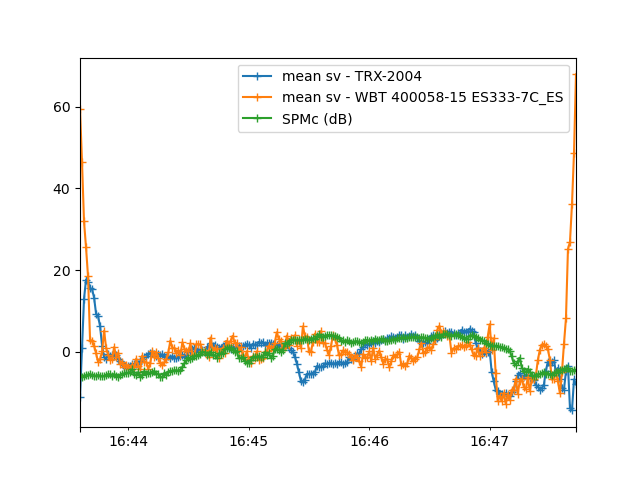

In [38]:
# merge data and plot
time_step = '1s'

merged_df = []
for name,d in data.items():
    merged_df.append(data[name].set_index('time').resample(time_step).mean())

data_vals = csv_data.copy()
data_vals = data_vals[data_vals['DepSM'] > 0]
data_vals = data_vals[['SPMc']]
data_vals['SPMc (dB)']=10*np.log10(data_vals['SPMc'])
data_vals = data_vals.resample(time_step).mean().dropna()
merged_df.append(data_vals)

merged_df_ = merged_df
merged_df = []
for df in merged_df_:
    if len(df) >0:
        merged_df.append(df)

merged_df = pd.concat(merged_df,axis=1).dropna()

merged_df_ = merged_df.copy()
del merged_df_['SPMc']
for k in merged_df_.keys():
    merged_df_[k]-=np.nanmedian(merged_df_[k])


merged_df_.plot(marker='+')

In [37]:
merged_df.to_csv(f'station({station})-layer-averages.csv')

In [ ]:
#merged_df

In [ ]:
import datetime

#modify max_depth if necessary
max_depth = 30 #m
time_resolution = 1 #s (subsampled not averaged)

#take min/max from merged_df
t0 = merged_df.index[0] - datetime.timedelta(minutes=5)
t1 = merged_df.index[-1] + datetime.timedelta(minutes=5)

In [ ]:
import importlib
import functions.util as util
importlib.reload(util)

#set minslant parameter
for k,e in tqdm(echogram_data.items()):
    #set maximum resolution
    e.set_x_axis_date_time(max_steps=100000,time_resolution=time_resolution, min_ping_time=t0.timestamp(), max_ping_time=t1.timestamp())
    e.set_y_axis_depth(max_steps=51200, max_depth=max_depth)

    # create image
    image, extent = e.build_image(progress=True)
    xim = util.image_to_xarray(image,extent,xdim='Ping time', ydim='Depth(m)')
    
    xim.to_netcdf(f'station({station})-{k}.nc', format='NETCDF4', engine="netcdf4")
    
    e.set_x_axis_date_time(max_steps=4000)
    e.set_y_axis_depth(max_steps=512, max_depth=30)

In [ ]:
t1-t0